# 03 — Sample dependence of the Hubble-law estimate

**Goal of this notebook:** test whether the estimated expansion rate changes when we change which supernovae are included and how the fit is defined.

This is the part that turns the project from a single line into a real data-analysis investigation. Nearby objects can have large peculiar velocities compared with the Hubble flow. Higher-redshift objects reduce that local-motion fraction, but they also make the raw luminosity-distance versus `cz` approximation less linear.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.pantheon import (
    clean_pantheon,
    fit_results_table,
    h0_for_lower_redshift_cuts,
    h0_for_redshift_bins,
    h0_for_redshift_cuts,
    load_cleaned,
    load_pantheon,
)
from src.plotting import plot_h0_by_redshift_cut


In [2]:
df = load_cleaned(PROJECT_ROOT / 'data/processed/pantheon_clean.csv')
df[['zHD', 'distance_mpc', 'hubble_distance_mpc', 'velocity_km_s']].describe()


,zHD,distance_mpc,hubble_distance_mpc,velocity_km_s
count,705.000000,705.000000,705.000000,705.000000
mean,0.044250,192.710308,179.657555,13265.714209
std,0.035694,164.972828,143.938670,10700.758663
min,0.010160,35.964995,35.603265,3045.891373
25%,0.021340,89.375812,87.510953,6397.571054
50%,0.030360,127.667396,123.872873,9101.699025
75%,0.050490,212.833506,202.022298,15136.521204
max,0.149400,799.981603,699.620975,44788.993225


## Experiment 1 — Cumulative redshift cuts

Here we fit $H_0$ several times, each time including all supernovae below a different maximum redshift.

This answers: *Does the result stabilize when we include more of the Hubble flow?*

The table includes several fit methods, all using the same preferred distance proxy `D_L/(1+z)`.


In [3]:
sample_methods = ['origin', 'free_intercept', 'huber', 'weighted_origin']
cuts = h0_for_redshift_cuts(
    df,
    cuts=[0.03, 0.05, 0.08, 0.10, 0.15],
    distance_col='hubble_distance_mpc',
    methods=sample_methods,
)
cuts.to_csv(PROJECT_ROOT / 'report/pantheon_h0_by_redshift_cut.csv', index=False)
cuts[['sample', 'method', 'H0', 'intercept', 'rmse', 'n']]


,sample,method,H0,intercept,rmse,n
0,z <= 0.03,"ordinary least squares, forced through origin",73.265883,0.000000,517.878507,347
1,z <= 0.03,"ordinary least squares, free intercept",69.183467,369.245685,509.561802,347
2,z <= 0.03,Huber robust regression,70.446097,260.297363,510.316576,347
3,z <= 0.03,"weighted least squares, forced through origin",73.266981,0.000000,517.878516,347
4,z <= 0.05,"ordinary least squares, forced through origin",72.911037,0.000000,601.447863,524
5,z <= 0.05,"ordinary least squares, free intercept",70.558774,288.657869,593.129518,524
6,z <= 0.05,Huber robust regression,71.459807,198.276044,594.252291,524
7,z <= 0.05,"weighted least squares, forced through origin",73.272794,0.000000,602.889085,524
8,z <= 0.08,"ordinary least squares, forced through origin",73.244419,0.000000,758.874305,606
9,z <= 0.08,"ordinary least squares, free intercept",72.376454,140.370138,756.196824,606


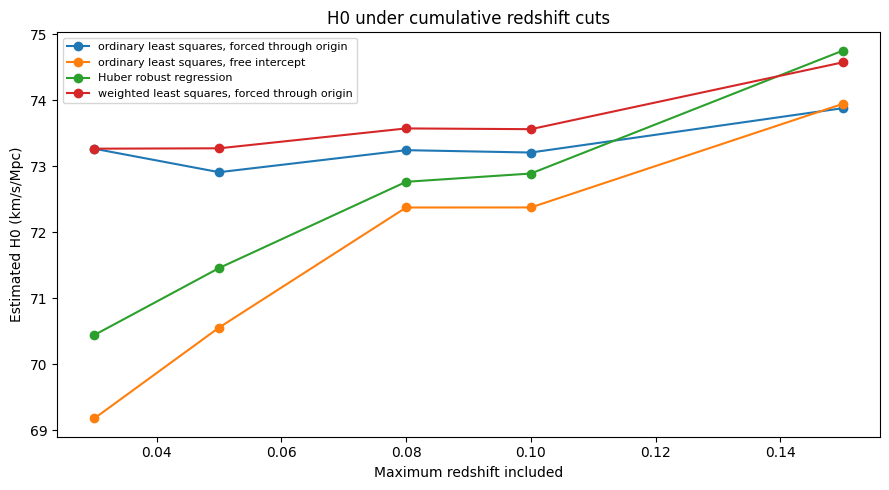

In [4]:
plt.figure(figsize=(9, 5))
for method, sub in cuts.groupby('method', sort=False):
    plt.plot(sub['z_max_cut'], sub['H0'], marker='o', label=method)
plt.xlabel('Maximum redshift included')
plt.ylabel('Estimated H0 (km/s/Mpc)')
plt.title('H0 under cumulative redshift cuts')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Interpretation of cumulative cuts

If the lowest-redshift cuts give unstable values, that is physically expected. At very small redshift, a galaxy or supernova host may have a peculiar velocity of hundreds of km/s caused by local gravitational motions. That is a large fraction of $cz$ when $z$ is small.

The useful question is not whether every cut gives the same number. It is whether the result changes in an understandable way and whether the preferred method is stable over reasonable cuts.


## Experiment 2 — Independent redshift bins

Cumulative cuts reuse many of the same objects. Bins ask a different question: *Do different redshift ranges prefer different slopes?*

The bins are noisier because each one contains fewer objects. That noisiness is the point: it shows why a single bin should not be treated as the final measurement.


In [5]:
bins = h0_for_redshift_bins(
    df,
    bins=[0.01, 0.03, 0.05, 0.08, 0.10, 0.15],
    distance_col='hubble_distance_mpc',
    methods=['origin', 'weighted_origin'],
)
bins.to_csv(PROJECT_ROOT / 'report/pantheon_h0_by_redshift_bin.csv', index=False)
bins[['bin', 'method', 'H0', 'rmse', 'n']]


,bin,method,H0,rmse,n
0,"(0.009000000000000001, 0.03]","ordinary least squares, forced through origin",73.265883,517.878507,347
1,"(0.009000000000000001, 0.03]","weighted least squares, forced through origin",73.266981,517.878516,347
2,"(0.03, 0.05]","ordinary least squares, forced through origin",72.690897,736.244341,177
3,"(0.03, 0.05]","weighted least squares, forced through origin",73.275477,741.846706,177
4,"(0.05, 0.08]","ordinary least squares, forced through origin",73.655470,1386.842063,82
5,"(0.05, 0.08]","weighted least squares, forced through origin",73.898777,1388.308380,82
6,"(0.08, 0.1]","ordinary least squares, forced through origin",72.959763,1454.781703,14
7,"(0.08, 0.1]","weighted least squares, forced through origin",73.481485,1466.761639,14
8,"(0.1, 0.15]","ordinary least squares, forced through origin",74.300819,2356.231643,85
9,"(0.1, 0.15]","weighted least squares, forced through origin",75.116892,2394.091345,85


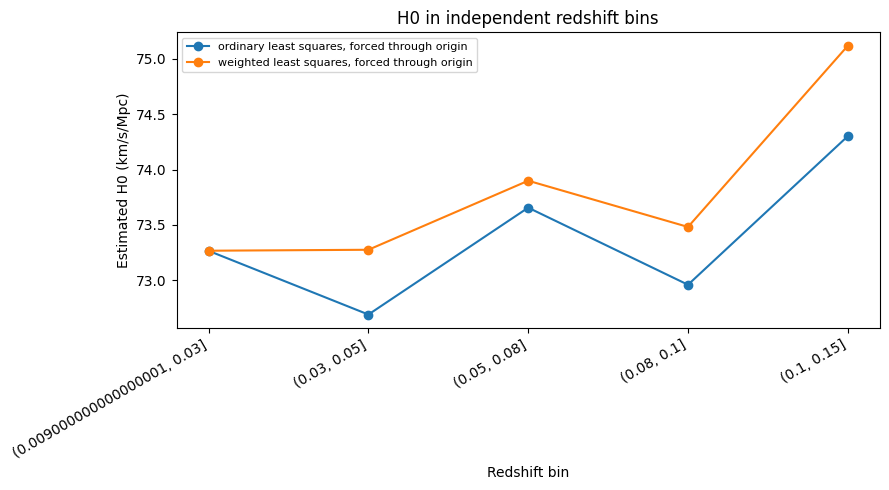

In [6]:
plt.figure(figsize=(9, 5))
for method, sub in bins.groupby('method', sort=False):
    plt.plot(range(len(sub)), sub['H0'], marker='o', label=method)
plt.xticks(range(len(bins['bin'].unique())), bins['bin'].unique(), rotation=30, ha='right')
plt.xlabel('Redshift bin')
plt.ylabel('Estimated H0 (km/s/Mpc)')
plt.title('H0 in independent redshift bins')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Experiment 3 — Lower redshift cut

Another common choice is to remove the nearest objects and keep a fixed upper cut. This directly tests the effect of local motions. If the nearest supernovae are noisy because of peculiar velocities, the slope should become more stable after a modest lower-redshift cut.


In [7]:
lower_cuts = h0_for_lower_redshift_cuts(
    df,
    zmins=[0.005, 0.01, 0.015, 0.02, 0.03],
    zmax=0.15,
    distance_col='hubble_distance_mpc',
    methods=sample_methods,
)
lower_cuts.to_csv(PROJECT_ROOT / 'report/pantheon_h0_by_lower_redshift_cut.csv', index=False)
lower_cuts[['sample', 'method', 'H0', 'intercept', 'rmse', 'n']]


,sample,method,H0,intercept,rmse,n
0,0.005 <= z <= 0.15,"ordinary least squares, forced through origin",73.880086,0.000000,1105.240998,705
1,0.005 <= z <= 0.15,"ordinary least squares, free intercept",73.944358,-18.948400,1105.177550,705
2,0.005 <= z <= 0.15,Huber robust regression,74.750534,-118.902125,1112.150152,705
3,0.005 <= z <= 0.15,"weighted least squares, forced through origin",74.573592,0.000000,1116.705666,705
4,0.01 <= z <= 0.15,"ordinary least squares, forced through origin",73.880086,0.000000,1105.240998,705
5,0.01 <= z <= 0.15,"ordinary least squares, free intercept",73.944358,-18.948400,1105.177550,705
6,0.01 <= z <= 0.15,Huber robust regression,74.750534,-118.902125,1112.150152,705
7,0.01 <= z <= 0.15,"weighted least squares, forced through origin",74.573592,0.000000,1116.705666,705
8,0.015 <= z <= 0.15,"ordinary least squares, forced through origin",73.897487,0.000000,1151.520883,643
9,0.015 <= z <= 0.15,"ordinary least squares, free intercept",73.857264,12.124914,1151.497634,643


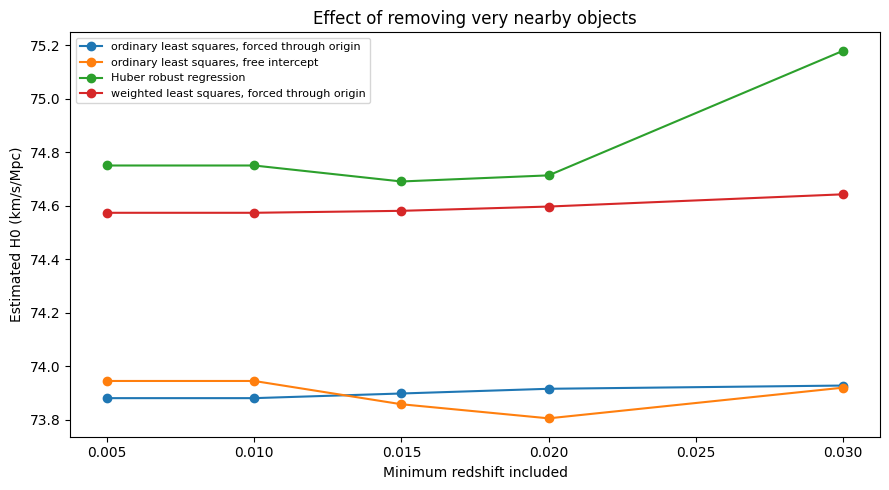

In [8]:
plt.figure(figsize=(9, 5))
for method, sub in lower_cuts.groupby('method', sort=False):
    plt.plot(sub['z_min_cut'], sub['H0'], marker='o', label=method)
plt.xlabel('Minimum redshift included')
plt.ylabel('Estimated H0 (km/s/Mpc)')
plt.title('Effect of removing very nearby objects')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Experiment 4 — Why the distance definition matters

This is the clearest sample-dependence diagnostic in the project. If we fit `cz` against raw luminosity distance, the result drifts downward as the maximum redshift increases. If we fit against `D_L/(1+z)`, the cumulative-cut trend is much flatter.

That does not make the simple model perfect. It simply shows that one apparent sample-dependence problem was partly caused by using a distance definition that is not ideal for the local linear Hubble law.


In [9]:
distance_cut_rows = []
for distance_col in ['distance_mpc', 'hubble_distance_mpc']:
    tmp = h0_for_redshift_cuts(
        df,
        cuts=[0.03, 0.05, 0.08, 0.10, 0.15],
        distance_col=distance_col,
        methods=['origin'],
    )
    distance_cut_rows.append(tmp)
distance_cuts = pd.concat(distance_cut_rows, ignore_index=True)
distance_cuts.to_csv(PROJECT_ROOT / 'report/pantheon_h0_distance_definition_by_cut.csv', index=False)
distance_cuts[['distance_definition', 'sample', 'H0', 'n']]


,distance_definition,sample,H0,n
0,luminosity distance D_L,z <= 0.03,71.603169,347
1,luminosity distance D_L,z <= 0.05,70.577545,524
2,luminosity distance D_L,z <= 0.08,69.861735,606
3,luminosity distance D_L,z <= 0.1,69.484694,620
4,luminosity distance D_L,z <= 0.15,67.015421,705
5,local Hubble-distance proxy D_L/(1+z),z <= 0.03,73.265883,347
6,local Hubble-distance proxy D_L/(1+z),z <= 0.05,72.911037,524
7,local Hubble-distance proxy D_L/(1+z),z <= 0.08,73.244419,606
8,local Hubble-distance proxy D_L/(1+z),z <= 0.1,73.208800,620
9,local Hubble-distance proxy D_L/(1+z),z <= 0.15,73.880086,705


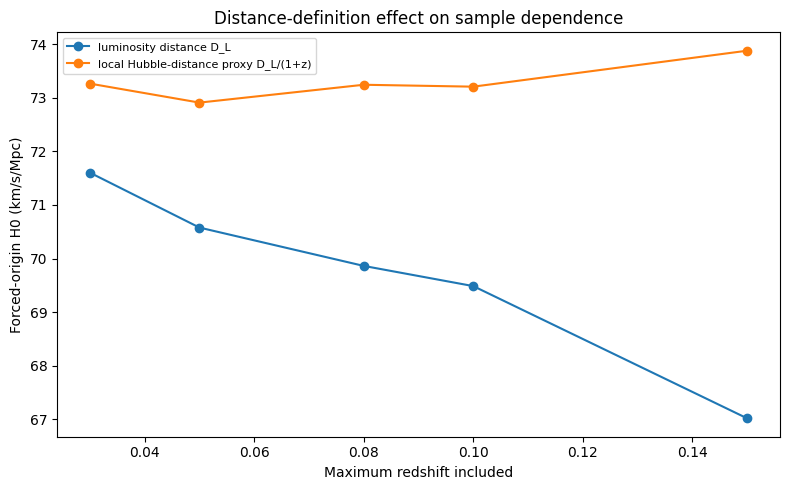

In [10]:
plt.figure(figsize=(8, 5))
for label, sub in distance_cuts.groupby('distance_definition', sort=False):
    plt.plot(sub['z_max_cut'], sub['H0'], marker='o', label=label)
plt.xlabel('Maximum redshift included')
plt.ylabel('Forced-origin H0 (km/s/Mpc)')
plt.title('Distance-definition effect on sample dependence')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Experiment 5 — Cepheid calibrator rows

Notebook 01 excludes Cepheid calibrator objects for the Hubble-flow fit. This check shows the effect of that choice. The comparison is useful because calibrators are not bad data; they are simply serving a different calibration purpose from the Hubble-flow sample.


In [11]:
raw = load_pantheon(PROJECT_ROOT / 'data/raw/Pantheon+SH0ES.dat')
calibrator_rows = []
for exclude_calibrators in [True, False]:
    variant, variant_summary = clean_pantheon(
        raw,
        z_min=0.01,
        z_max=0.15,
        exclude_calibrators=exclude_calibrators,
    )
    label = 'calibrators excluded' if exclude_calibrators else 'calibrators included'
    table = fit_results_table(
        variant,
        distance_cols=['hubble_distance_mpc'],
        methods=['origin', 'weighted_origin'],
    )
    table['calibrator_choice'] = label
    table['n_clean'] = len(variant)
    calibrator_rows.append(table)
calibrator_comparison = pd.concat(calibrator_rows, ignore_index=True)
calibrator_comparison.to_csv(PROJECT_ROOT / 'report/pantheon_h0_calibrator_choice.csv', index=False)
calibrator_comparison[['calibrator_choice', 'method', 'H0', 'rmse', 'n_clean']]


,calibrator_choice,method,H0,rmse,n_clean
0,calibrators excluded,"ordinary least squares, forced through origin",73.880086,1105.240998,705
1,calibrators excluded,"weighted least squares, forced through origin",74.573592,1116.705666,705
2,calibrators included,"ordinary least squares, forced through origin",73.877417,1098.420848,715
3,calibrators included,"weighted least squares, forced through origin",74.572660,1109.860894,715


## Save summary figure


In [12]:
plot_h0_by_redshift_cut(cuts, PROJECT_ROOT / 'figures/pantheon_h0_by_redshift_cut.png')
print('Saved figures and CSV tables.')


Saved figures and CSV tables.


## Sample-dependence conclusion

The Hubble-law slope is not just a property of a formula; it also depends on data selection, distance definition, and fit method.

The clearer story after these checks is:

- very nearby objects are more affected by peculiar velocities;
- cumulative redshift cuts should be compared with independent redshift bins;
- raw luminosity distance makes the simple `cz = H0 d` slope drift with redshift;
- using `D_L/(1+z)` makes the local linear fit much more stable;
- weighted and robust fits are diagnostics, not magic replacements for a full covariance analysis.

This gives the project a defensible scientific conclusion: official supernova data support the expansion relation, but an educational measurement of the local expansion rate is sample- and method-dependent.
